In [37]:
# !pip list | grep qiskit
# !pip install --upgrade pip
# !pip uninstall qiskit -y
# !pip uninstall qiskit qiskit-aer qiskit-ibmq-provider qiskit-terra -y
# !rm -rf /opt/homebrew/lib/python3.10/site-packages/qiskit
# !pip list | grep qiskit
# !conda remove -n qiskit_env --all
# !pip install qiskit-terra
# !pip install qiskit-aer
# !pip install qiskit-ibmq-provider
# !pip install qiskit-terra==0.46.3 
# !pip install qiskit-ibmq-provider==0.20.2
# !pip install qiskit-aer==0.17.2
# !pip install -U qiskit
# !pip install 'qiskit[visualization]'
# !pip install numpy
# !pip install qiskit-algorithms


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
# from qiskit_aer import AerSimulator
# from qiskit.visualization import plot_histogram

In [23]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
print(result[0].data.meas.get_counts())

{'11': 509, '00': 515}


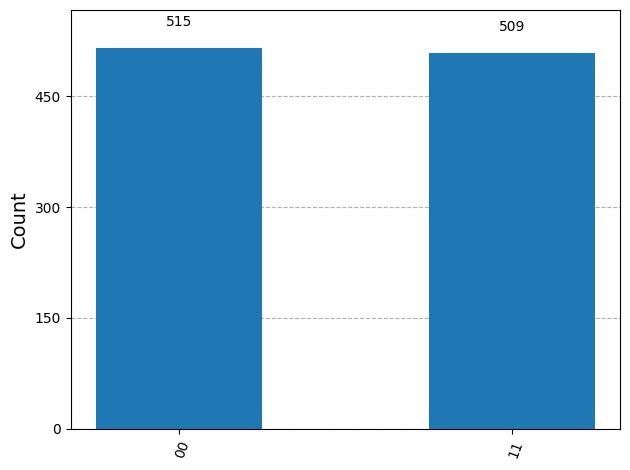

In [25]:
counts = result[0].data.meas.get_counts()
plot_histogram(counts)

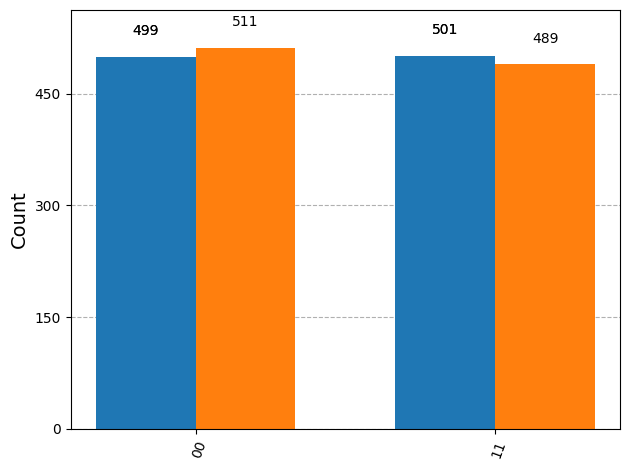

In [20]:
counts1 = {'00': 499, '11': 501}
counts2 = {'00': 511, '11': 489}

data = [counts1, counts2]
plot_histogram(data)

In [6]:
circuit = QuantumCircuit(2, 2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure([0, 1], [0, 1])

In [36]:
# !pip install qiskit --upgrade

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms import TimeEvolutionProblem
from qiskit.circuit.library import PauliEvolutionGate

In [6]:
hamiltonian = SparsePauliOp.from_list([
    ("ZZ", 1.0),
    ("XI", 0.5)
])

In [20]:
#### Hamiltonian 

def pauli_string(N, ops):
    """
    N: number of qubits
    ops: dict like {qubit_index: 'X'/'Y'/'Z'}
    """
    s = ["I"] * N
    for qubit, op in ops.items():
        s[qubit] = op
    return "".join(s)


def build_J(N, a):
    
    positions = list(range(N)) 
    J = {}

    for i in range(N):
        for j in range(i + 1, N):
            dist = abs(positions[i] - positions[j])
            d_pbc = min(dist, N - dist)   # key line for PBC
            J[(i, j)] = 1.0 / (d_pbc ** a)

    return J


terms = []

# X fields
N=4
h=2.0
a=1.8
J=build_J(N, a)
for i in range(N):
    terms.append((pauli_string(N, {i: "X"}), h))

# ZZ interactions
for (i, j), val in J.items():
    terms.append((pauli_string(N, {i: "Z", j: "Z"}), val))
    
print(terms)   
hamiltonian = SparsePauliOp.from_list(terms) 

[('XIII', 2.0), ('IXII', 2.0), ('IIXI', 2.0), ('IIIX', 2.0), ('ZZII', 1.0), ('ZIZI', 0.2871745887492588), ('ZIIZ', 1.0), ('IZZI', 1.0), ('IZIZ', 0.2871745887492588), ('IIZZ', 1.0)]


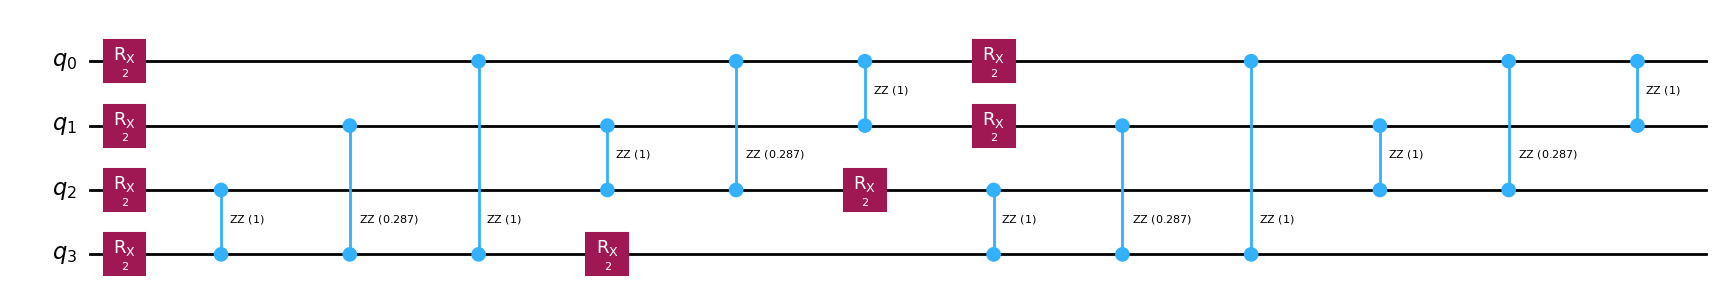

In [24]:
### using Lie-Trotter to synthesize the evolution gate for the Hamiltonian ###
from qiskit.synthesis import LieTrotter

evolution_gate = PauliEvolutionGate(
    hamiltonian,
    time=1.0,
    synthesis=LieTrotter(reps=2)
)

# print(evolution_gate.operator)
## application of the circuit to qbits  and visualization##
qc = QuantumCircuit(N)
qc.append(evolution_gate, list(range(N)))

de_circuit=qc.decompose().draw("mpl")

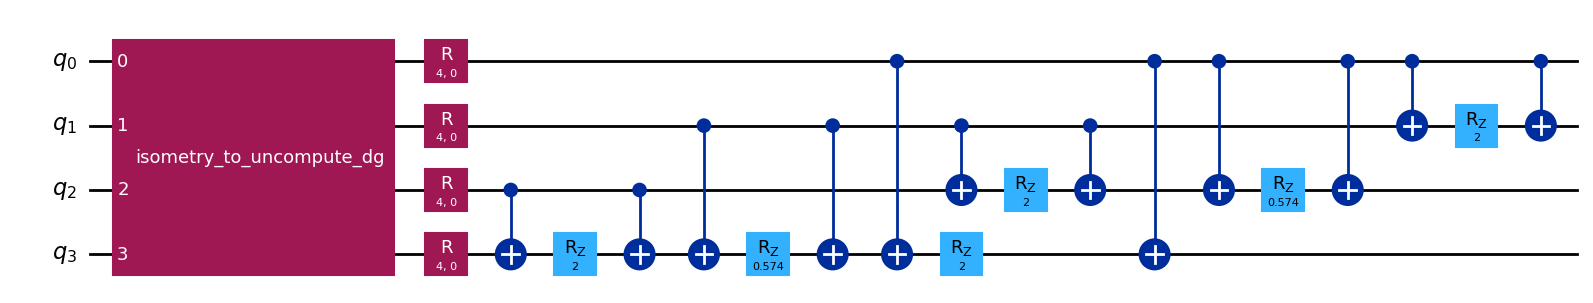

In [35]:
###--- time evolution of an initial state through a time independent Hamiltonian
# using TrotterQRTE Trotterization--###
from qiskit.quantum_info import Statevector
from qiskit_algorithms import TrotterQRTE
initial_state = Statevector.from_label("1000")
problem = TimeEvolutionProblem(hamiltonian, initial_state=initial_state, time=1.0)
trotter = TrotterQRTE()
result = trotter.evolve(problem)

# circuit = result.evolved_state.draw("mpl")
de_circuit=result.evolved_state.decompose(reps=2).decompose("disentangler_dg").decompose(
    "multiplex1_reverse_dg"
).draw("mpl")